# RAGAS black-box RAGAS filter training on Merged ASQA/MS MARCO/WikiEval dataset

Notebook này tạo feature table theo từng sample từ `labeled_merged.csv`, chỉ dùng các metric black-box của RAGAS khi **không có ground truth**, sau đó train một dãy classifier từ cơ bản đến mạnh hơn.

Output chính:
- bảng so sánh các mô hình classifier
- model tốt nhất được lưu ra disk để dùng lại
- test lại trên các tập test lẻ tẻ của từng dataset để xem hiệu quả generalization

## Imports and setup

In [2]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import ast
import importlib
import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os
sys.path.append('..')

import src.filtering.ragas as _ragas_mod
importlib.reload(_ragas_mod)

from src.filtering.ragas import RAGAS
from src.filtering.ragas_feature_extractor import RagasFeatureExtractor
from src.filtering.ragas_filter_trainer import RagasFilterTrainer
from src.filtering.ragas_filter import RagasFilter
from src.evaluation import plot_evaluation_results

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
HUGGINGFACE_API_KEY = os.getenv("HUGGINGFACE_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")


XGBOOST_AVAILABLE = importlib.util.find_spec("xgboost") is not None
XGBClassifier = importlib.import_module("xgboost").XGBClassifier if XGBOOST_AVAILABLE else None

sys.path.append('..')


pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)
np.random.seed(42)

print(f"XGBOOST_AVAILABLE = {XGBOOST_AVAILABLE}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
XGBOOST_AVAILABLE = True


In [3]:
DATA_PATH = Path('../data/labeled_merged.csv')
OUTPUT_DIR = Path('../results/ragas_filter')
OUTPUT_TRAIN_DIR = Path('../results/ragas_filter/merged')
MODEL_DIR = Path('../models/ragas_filter')

## Imports data and initialize evaluator

In [4]:
df = pd.read_csv(DATA_PATH)
df["label"] = df["label"].astype(int)

expected_columns = {"id", "question", "answer", "context", "label"}
missing_columns = expected_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing columns in CSV: {sorted(missing_columns)}")

print(df.shape)
display(df.head())
print(df["label"].value_counts(dropna=False).sort_index())

(9806, 6)


,id,question,context,answer,label,dataset
0,asqa_0,When does the new bunk'd come out?,"- (List of Bunk'd episodes) The new bunk'd episode 41 comes out on April 21, 2017, episode 42 comes out on April 28,...","The new bunk'd episode 41 comes out on April 21, 2017, episode 42 comes out on April 28, 2017 and episode 42 is due ...",1,asqa
1,asqa_1,Who won the 2016 ncaa football national championship?,- (2016 College Football Playoff National Championship) The 2015 - 2016 season's ncaa national football championship...,The 2015 - 2016 season's ncaa national football championship game was played between the Clemson Tigers and the Alab...,1,asqa
2,asqa_2,When was the last time the death penalty was used in pa?,"- (QA_1) As of 2017, when was the last time the death penalty was carried out in PA? July 6, 1999.\n- (QA_2) As of 2...","The last time the death penalty was used in pa was on July 6, 1999.",1,asqa
3,asqa_3,Where will failure of the left ventricle cause increased pressure?,"- (Heart failure) ""Backward"" failure of the left ventricle causes congestion of the lungs' blood vessels, and theref...","""Backward"" failure of the left ventricle causes congestion of the lungs' blood vessels, and therefore causes increas...",1,asqa
4,asqa_4,Who won the war between ethiopia and italy?,- (Second Italo-Ethiopian War) The first war between Italy and Ethiopia took place from 1895 to 1896. This war was w...,The first war between Italy and Ethiopia took place from 1895 to 1896. This war was won by the Ethiopian army after ...,1,asqa


label
0    4903
1    4903
Name: count, dtype: int64


## RAGAs feature extraction

In [5]:
# Black-box RAGAS metrics: no ground-truth dependent scores
# We intentionally skip answer_correctness / answer_similarity.
metric_names = [
    "faithfulness",
    "answer_relevancy",
    "context_relevancy",
]

evaluator = RAGAS(
    metrics=metric_names,

    # OpenAI models
    llm_model="gpt-4o-mini",
    embedding_model="text-embedding-3-small",

    # optional
    api_key=OPENAI_API_KEY,

    # optional
    temperature=0,
)


extractor = RagasFeatureExtractor(ragas_evaluator=evaluator, feature_cols=metric_names)
feature_df = extractor.transform(data=df, 
                                feature_path=OUTPUT_TRAIN_DIR / "merged_ragas_features.csv",
                                checkpoint_path=OUTPUT_TRAIN_DIR / "merged_ragas_checkpoints.csv")
print(f"Save RAGAS features to {OUTPUT_TRAIN_DIR / 'merged_ragas_features.csv'}")
print(feature_df.shape)
display(feature_df.describe().T)
display(feature_df.head())

Resuming from sample 9806
Save RAGAS features to ..\results\ragas_filter\merged\merged_ragas_features.csv
(9806, 6)


,count,mean,std,min,25%,50%,75%,max
faithfulness,9806.0,0.681684,0.345794,0.0,0.400000,0.800000,1.000000,1.0
answer_relevancy,9806.0,0.732503,0.211706,0.0,0.668929,0.786409,0.868929,1.0
context_relevancy,9806.0,0.204840,0.179689,0.0,0.090909,0.142857,0.250000,1.0
label,9806.0,0.500000,0.500025,0.0,0.000000,0.500000,1.000000,1.0


,id,faithfulness,answer_relevancy,context_relevancy,label,dataset
0,asqa_0,0.666667,0.726235,0.090909,1,asqa
1,asqa_1,1.000000,0.957490,0.111111,1,asqa
2,asqa_2,1.000000,0.965820,0.111111,1,asqa
3,asqa_3,1.000000,0.641608,0.125000,1,asqa
4,asqa_4,1.000000,0.800938,0.214286,1,asqa


## Filter Models Training

Load features and labels

In [6]:
feature_df = pd.read_csv(OUTPUT_TRAIN_DIR / "merged_ragas_features.csv")
print(feature_df.shape)

(9806, 6)


Data splitting

In [10]:
feature_cols = [col for col in feature_df.columns if col not in {"id", "label", "dataset"}]
X = feature_df[feature_cols].copy()
y = feature_df["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

Model training:
- Logistic Regression
- Random Forest
- Gradient Boosting
- HistGradient Boosting
- Extra Trees
- XGBoost *(if available)*


In [11]:
models = {
    "logistic_regression": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                random_state=42,
                class_weight="balanced_subsample",
                n_jobs=-1,
            )),
        ]
    ),
    "gradient_boosting": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(random_state=42)),
        ]
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=300,
        max_leaf_nodes=31,
        random_state=42,
    ),
    "extra_trees": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=500,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1,
            )),
        ]
    ),
}

if XGBOOST_AVAILABLE:
    models["xgboost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        missing=np.nan,
    )

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Features: {feature_cols}")
print(f"Models: {list(models.keys())}")

Train size: 7844 | Test size: 1962
Features: ['faithfulness', 'answer_relevancy', 'context_relevancy']
Models: ['logistic_regression', 'random_forest', 'gradient_boosting', 'hist_gradient_boosting', 'extra_trees', 'xgboost']


Evaluate and compare models, save results to CSV

In [12]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
    }

    if hasattr(model, "predict_proba"):
        try:
            probabilities = model.predict_proba(X_test)[:, 1]
            metrics["roc_auc"] = roc_auc_score(y_test, probabilities)
        except Exception:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    return metrics, predictions


results = []
trained_models = {}

for name, model in models.items():
    metrics, _ = evaluate_classifier(model, X_train, X_test, y_train, y_test)
    results.append({"model": name, **metrics})
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(["f1", "accuracy"], ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print(f"Best model: {best_model_name}")

,model,accuracy,precision,recall,f1,roc_auc
0,gradient_boosting,0.905708,0.937363,0.869521,0.902168,0.966364
1,xgboost,0.898573,0.925926,0.866463,0.895208,0.964580
2,hist_gradient_boosting,0.895515,0.909283,0.878695,0.893727,0.960776
3,random_forest,0.889399,0.907249,0.867482,0.886920,0.954123
4,extra_trees,0.882773,0.902465,0.858308,0.879833,0.937605
5,logistic_regression,0.801733,0.773567,0.853211,0.811440,0.904573


Best model: gradient_boosting


In [13]:
import joblib

MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_model_path = MODEL_DIR / f"{best_model_name}-merged.joblib"
joblib.dump(best_model, best_model_path)

print(f"Saved best model to: {best_model_path}")

final_predictions = best_model.predict(X_test)
print(classification_report(y_test, final_predictions, zero_division=0))

Saved best model to: ..\models\ragas_filter\gradient_boosting-merged.joblib
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       981
           1       0.94      0.87      0.90       981

    accuracy                           0.91      1962
   macro avg       0.91      0.91      0.91      1962
weighted avg       0.91      0.91      0.91      1962



Best model: Gradient Boosting Classifier.

Try to find feature importance from the best model.

In [14]:
def unwrap_estimator(model):
    if hasattr(model, "named_steps"):
        # lấy step cuối trong Pipeline
        return list(model.named_steps.values())[-1]
    return model


def get_feature_importance(model, feature_cols):
    clf = unwrap_estimator(model)

    if not hasattr(clf, "feature_importances_"):
        raise ValueError(f"{type(clf)} không có feature_importances_")

    importance_df = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance": clf.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    importance_df["importance_pct"] = (
        importance_df["importance"] / importance_df["importance"].sum()
    )

    return importance_df

In [15]:
# load model from disk
# get model from the only .joblib file in the model directory
model_files = list(MODEL_DIR.glob("*.joblib"))

best_model = joblib.load(model_files[0])
importance_df = get_feature_importance(best_model, feature_cols)
display(importance_df)

,feature,importance,importance_pct
0,faithfulness,0.913671,0.913671
1,context_relevancy,0.077449,0.077449
2,answer_relevancy,0.008880,0.008880


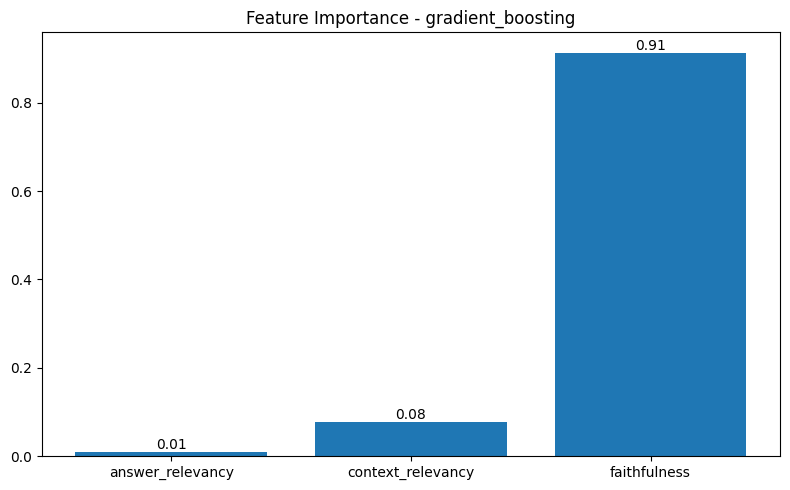

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1],
)
importances = importance_df["importance"].values
for i, (feature, importance) in enumerate(zip(importance_df["feature"][::-1], importance_df["importance"][::-1])):
    plt.text(i, importance, f"{importance:.2f}", ha="center", va="bottom")
plt.title(f"Feature Importance - {best_model_name}")
plt.tight_layout()
plt.show()

Find the distribution of accuracy, precision, recall, F1-score across different datasets (MS MARCO, WikiEval, ASQA) to see if the model performs consistently or if there are any dataset-specific patterns. (use 'dataset' column in feature_df)

In [41]:
# Find the distribution of accuracy, precision, recall, F1-score across different datasets (MS MARCO, WikiEval, ASQA) on test set only
test_df = feature_df.loc[X_test.index].copy()
test_df["predicted_label"] = final_predictions
dataset_metrics = []
for dataset_name, group in test_df.groupby("dataset"):
    acc = accuracy_score(group["label"], group["predicted_label"])
    prec = precision_score(group["label"], group["predicted_label"], zero_division=0)
    rec = recall_score(group["label"], group["predicted_label"], zero_division=0)
    f1 = f1_score(group["label"], group["predicted_label"], zero_division=0)
    dataset_metrics.append({
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    })
dataset_metrics_df = pd.DataFrame(dataset_metrics)
display(dataset_metrics_df)


,dataset,accuracy,precision,recall,f1
0,asqa,0.899256,0.933251,0.860889,0.895611
1,msmarco,0.958333,0.977273,0.934783,0.955556
2,wikieval,0.956522,0.923077,1.000000,0.960000


## Test on other datasets (optional)

In [23]:
MS_PATH = Path('../data/ms-marco/labeled_msmarco.csv')
WIKI_PATH = Path('../data/wikiEval/labeled_wikieval.csv')
ASQA_PATH = Path('../data/asqa/labeled_asqa_test.csv')
OUTPUT_FILTER = OUTPUT_DIR / "classification"

In [24]:
metric_names = [
    "faithfulness",
    "answer_relevancy",
    "context_relevancy",
]

evaluator = RAGAS(
    metrics=metric_names,

    # OpenAI models
    llm_model="gpt-4o-mini",
    embedding_model="text-embedding-3-small",

    # optional
    api_key=OPENAI_API_KEY,

    # optional
    temperature=0,
)


extractor = RagasFeatureExtractor(ragas_evaluator=evaluator, feature_cols=metric_names)

ragas_filter = RagasFilter(model_path=best_model_path, feature_extractor=extractor, output_dir=OUTPUT_FILTER)

### ASQA Test set evaluation (re-evaluation)
Use test set of ASQA to evaluate the best model trained on the training set, and compare with the original labels.

In [25]:
asqa_df = pd.read_csv(ASQA_PATH)
print(asqa_df.shape)
display(asqa_df.head())

(1742, 5)


,id,question,context,answer,label
0,asqa_1881_hallu,What is the new wizard of oz movie called?,"- (Oz the Great and Powerful) There are several new ""Wizard of Oz"" movies. ""After the Wizard"" is an independent 2011...","There are several new ""Wizard of Oz"" movies. ""After the Wizard"" is an independent 2012 fantasy film written and dire...",0
1,asqa_9_hallu,When does doctor strange get the infinity stone?,"- (Infinity Gems) In the animated direct-to-video film, Doctor Strange: The Sorcerer Supreme, Doctor Strange first g...","In the animated direct-to-video film, Doctor Strange: The Sorcerer Supreme, Doctor Strange first gets the Eye of Aga...",0
2,asqa_903,Where is the book of psalms in the bible?,"- (Psalms) The Book of Psalms is the first book of the ""Ketuvim"", or ""Writings"", the third section of the Hebrew Bib...","The Book of Psalms is the first book of the ""Ketuvim"", or ""Writings"", the third section of the Hebrew Bible. Psalms ...",1
3,asqa_2652_hallu,Who plays the voice of tiana in princess and the frog?,- (QA_1) Who plays the voice of Tiana as a child in Princess and the Frog? Elizabeth M. Dampier.\r\n- (QA_2) Who pla...,"The role of Tiana in Disney's 2009 film ""The Princess and the Frog"" is voiced by Beyoncé, while Elizabeth M. Dampier...",0
4,asqa_1707_hallu,Which actress stars as a mom in the film diary of a wimpy kid the long haul?,- (Diary of a Wimpy Kid: The Long Haul (film)) Several actresses star as a mom in the 2017 film Diary of a Wimpy Kid...,"Several actresses star as a mom in the 2017 film Diary of a Wimpy Kid: The Long Haul. In the film, actress Jennifer ...",0


Feature extraction on ASQA test set

In [26]:
asqa_feature_df = extractor.transform(data=asqa_df,
                                    feature_path=OUTPUT_FILTER / "asqa_test_ragas_features.csv",
                                    checkpoint_path=OUTPUT_FILTER / "asqa_test_ragas_checkpoints.csv")
print(f"Save RAGAS features to {OUTPUT_FILTER / 'asqa_test_ragas_features.csv'}")
print(asqa_feature_df.shape)
display(asqa_feature_df.describe().T)
display(asqa_feature_df.head())

Resuming from sample 1742
Save RAGAS features to ..\results\ragas_filter\classification\asqa_test_ragas_features.csv
(1742, 5)


,count,mean,std,min,25%,50%,75%,max
faithfulness,1742.0,0.699009,0.325655,0.0,0.500000,0.800000,1.000000,1.0
answer_relevancy,1742.0,0.736562,0.210139,0.0,0.673853,0.789776,0.872035,1.0
context_relevancy,1742.0,0.172787,0.125687,0.0,0.090909,0.125000,0.222222,1.0
label,1742.0,0.500000,0.500144,0.0,0.000000,0.500000,1.000000,1.0


,id,faithfulness,answer_relevancy,context_relevancy,label
0,asqa_1881_hallu,0.666667,0.795519,0.066667,0
1,asqa_9_hallu,0.750000,0.636572,0.095238,0
2,asqa_903,1.000000,0.637074,0.100000,1
3,asqa_2652_hallu,0.200000,0.911755,0.166667,0
4,asqa_1707_hallu,0.666667,0.932241,0.250000,0


Run inference model, evaluate results, and save to CSV.


Classification Metrics for ASQA Test Set:
  accuracy: 0.9081515499425947
  precision: 0.927797833935018
  recall: 0.8851894374282434
  f1: 0.9059929494712103
  roc_auc: 0.9666271662090501


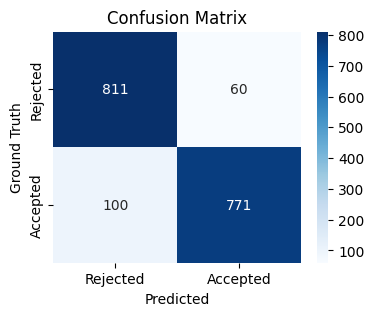

,precision,recall,f1-score,support
0,0.8902,0.9311,0.9102,871.0000
1,0.9278,0.8852,0.9060,871.0000
accuracy,0.9082,0.9082,0.9082,0.9082
macro avg,0.9090,0.9082,0.9081,1742.0000
weighted avg,0.9090,0.9082,0.9081,1742.0000


In [27]:
asqa_filter = ragas_filter.run(data=asqa_df, feature_df=asqa_feature_df,
                               filter_path=OUTPUT_FILTER / "asqa_test_filtered-2.csv",
                               data_name="asqa", eval_mode="classification")

plot_evaluation_results(asqa_filter['evaluation'], data_name="ASQA Test Set")

### MS Marco dataset
Use 500 longest answers from MS Marco, synthesize to 1000 sample with hallucination.
Use RAGAS features, and apply the best model to predict labels.

In [28]:
ms_marco_df = pd.read_csv(MS_PATH)
print(ms_marco_df.shape)
display(ms_marco_df.head())

(1000, 5)


,id,question,context,answer,label
0,10736,buying a car dealer vs. private seller,[P1] Source: http://www.consumerhelp.ie/buying-car-dealer-private\nBuying a car-dealer or private seller. There are ...,Traders are often called “dealers” and sell cars as part of their business.Private sellers generally have only one c...,1
1,12719,convert dollar pay into salary to twice a month,[P1] Source: http://www.ehow.com/how_12044390_convert-annual-salary-being-paid-twice-month.html\nInstructions. Deter...,"Determine what your paydays will be throughout the year. Often, employees who receive bimonthly paychecks have payda...",1
2,17806,how to plant dwarf apple trees,[P1] Source: http://www.gardenguides.com/79766-plant-dwarf-apple-trees.html\nStep 1. Locate a site for the dwarf app...,Locate a site for the dwarf apple tree where it will get at least six hours or more of full sun during the day. The ...,1
3,14675,what arthritis is,[P1] Source: http://www.healthline.com/health/arthritis\nArthritis is inflammation of the joints (the points where b...,Arthritis is inflammation of the joints (the points where bones meet) in one or more areas of the body.Arthritis is ...,1
4,16014,how to record audio with iphone,[P1] Source: http://www.solveyourtech.com/record-audio-iphone-5/\nYou can learn how to record audio on an iPhone usi...,"1: Open the Voice Memos app. If you cannot find it it might be in a Utilities folder, as in the screenshot below. Yo...",1


Feature extraction using RAGAS Evaluator.

In [29]:
ms_feature_df = extractor.transform(data=ms_marco_df, 
                                    feature_path=OUTPUT_FILTER/"msmarco_ragas_features.csv",
                                    checkpoint_path=OUTPUT_FILTER/"msmarco_ragas_checkpoints.csv")
print(f"Save RAGAS features to {OUTPUT_FILTER/'msmarco_ragas_features.csv'}")
print(ms_feature_df.shape)
display(ms_feature_df.head())
display(ms_feature_df.describe().T)

Resuming from sample 1000
Save RAGAS features to ..\results\ragas_filter\classification\msmarco_ragas_features.csv
(1000, 5)


,id,faithfulness,answer_relevancy,context_relevancy,label
0,10736,1.0,0.763581,0.857143,1
1,12719,1.0,0.609449,0.875000,1
2,17806,1.0,0.871016,1.000000,1
3,14675,1.0,0.697597,0.636364,1
4,16014,1.0,0.766354,0.666667,1


,count,mean,std,min,25%,50%,75%,max
faithfulness,1000.0,0.534171,0.449368,0.0,0.089015,0.500000,1.000000,1.0
answer_relevancy,1000.0,0.697043,0.214969,0.0,0.619082,0.747646,0.846537,1.0
context_relevancy,1000.0,0.497798,0.289702,0.0,0.250000,0.480769,0.750000,1.0
label,1000.0,0.500000,0.500250,0.0,0.000000,0.500000,1.000000,1.0


Run inference model, evaluate results, and save to CSV.


Classification Metrics for MS MARCO:
  accuracy: 0.969
  precision: 0.9895615866388309
  recall: 0.948
  f1: 0.9683350357507661
  roc_auc: 0.990424


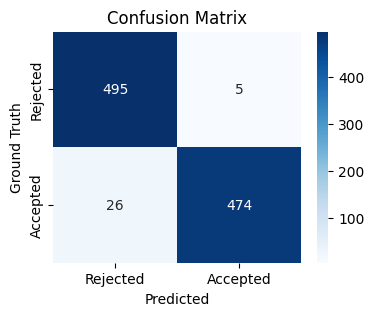

,precision,recall,f1-score,support
0,0.9501,0.990,0.9696,500.000
1,0.9896,0.948,0.9683,500.000
accuracy,0.9690,0.969,0.9690,0.969
macro avg,0.9698,0.969,0.9690,1000.000
weighted avg,0.9698,0.969,0.9690,1000.000


In [30]:
msmacro_filter= ragas_filter.run(data=ms_marco_df, feature_df=ms_feature_df,
                                                    filter_path=OUTPUT_FILTER/"msmarco_filtered-2.csv",
                                                    data_name="msmarco", eval_mode="classification")

plot_evaluation_results(msmacro_filter["evaluation"], "MS MARCO")

### WikiEval dataset
Use full WikiEval dataset, synthesize hallucination samples. 

In [31]:
wikieval_df = pd.read_csv(WIKI_PATH)
print(wikieval_df.shape)
display(wikieval_df.head())

(100, 5)


,id,question,context,answer,label
0,0_pos,"When is the scheduled launch date and time for the PSLV-C56 mission, and where will it be launched from?",The PSLV-C56 is the 58th mission of Indian Space Research Organisation's Polar Satellite Launch Vehicle (PSLV) and t...,"The PSLV-C56 mission is scheduled to be launched on Sunday, 30 July 2023 at 06:30 IST / 01:00 UTC. It will be launch...",1
1,0_neg,"When is the scheduled launch date and time for the PSLV-C56 mission, and where will it be launched from?",The PSLV-C56 is the 58th mission of Indian Space Research Organisation's Polar Satellite Launch Vehicle (PSLV) and t...,The scheduled launch date and time for the PSLV-C56 mission have not been provided.The PSLV-C56 mission is an import...,0
2,1_pos,What is the objective of the Uzbekistan-Afghanistan-Pakistan Railway Project and how is it expected to enhance trade...,The Uzbekistan–Afghanistan–Pakistan Railway Project is an extensive project undertaking with the objective of creati...,The objective of the Uzbekistan-Afghanistan-Pakistan Railway Project is to create a direct railway link between Uzbe...,1
3,1_neg,What is the objective of the Uzbekistan-Afghanistan-Pakistan Railway Project and how is it expected to enhance trade...,The Uzbekistan–Afghanistan–Pakistan Railway Project is an extensive project undertaking with the objective of creati...,The objective of the Uzbekistan-Afghanistan-Pakistan Railway Project is to establish a railway network connecting th...,0
4,2_pos,When was PharmaCann founded and what is its headquarters location?,"Found in 2014 by Theodore Scott, PharmaCann is an American cannabis company headquartered in the state of Illinois, ...",PharmaCann was founded in 2014 by Theodore Scott. Its headquarters is located in the state of Illinois.,1


Ragas feature extraction

In [32]:
wikieval_feature_df = extractor.transform(data=wikieval_df,
                                        feature_path=OUTPUT_FILTER/"wikieval_ragas_features.csv",
                                        checkpoint_path=OUTPUT_FILTER/"wikieval_ragas_checkpoints.csv")
print(f"Save RAGAS features to {OUTPUT_FILTER/'wikieval_ragas_features.csv'}")
print(wikieval_feature_df.shape)
display(wikieval_feature_df.head())
display(wikieval_feature_df.describe().T)

Resuming from sample 100
Save RAGAS features to ..\results\ragas_filter\classification\wikieval_ragas_features.csv
(100, 5)


,id,faithfulness,answer_relevancy,context_relevancy,label
0,0_pos,1.000000,0.916225,0.250000,1
1,0_neg,0.500000,0.000000,0.250000,0
2,1_pos,1.000000,0.872695,0.666667,1
3,1_neg,0.666667,0.872695,0.666667,0
4,2_pos,1.000000,0.988983,0.500000,1


,count,mean,std,min,25%,50%,75%,max
faithfulness,100.0,0.700448,0.353197,0.000000,0.383333,0.910714,1.000000,1.0
answer_relevancy,100.0,0.672493,0.384992,0.000000,0.661520,0.870860,0.921378,1.0
context_relevancy,100.0,0.222846,0.189309,0.015873,0.094866,0.178375,0.277778,1.0
label,100.0,0.500000,0.502519,0.000000,0.000000,0.500000,1.000000,1.0


Run inference model, evaluate results, and save to CSV.


Classification Metrics for WikiEval:
  accuracy: 0.92
  precision: 0.92
  recall: 0.92
  f1: 0.92
  roc_auc: 0.9776


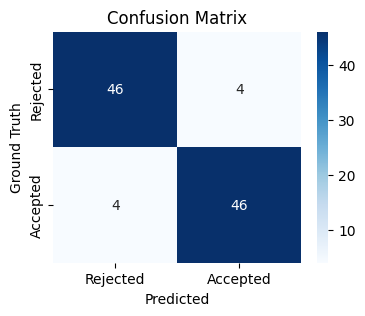

,precision,recall,f1-score,support
0,0.92,0.92,0.92,50.00
1,0.92,0.92,0.92,50.00
accuracy,0.92,0.92,0.92,0.92
macro avg,0.92,0.92,0.92,100.00
weighted avg,0.92,0.92,0.92,100.00


In [33]:
wikieval_filter = ragas_filter.run(data=wikieval_df, feature_df=wikieval_feature_df,
                                                    filter_path=OUTPUT_FILTER/"wikieval_filtered-2.csv", 
                                                    data_name="wikieval", eval_mode="classification")
plot_evaluation_results(wikieval_filter["evaluation"], "WikiEval")

Concat 3 dataset results, and save to `ragas_filter_sumary.csv`

In [ ]:
summary_specs = [
    ("ASQA", asqa_filter, OUTPUT_FILTER / "asqa_test_filtered-2.csv"),
    ("MS MARCO", msmacro_filter, OUTPUT_FILTER / "msmacro_filtered-2.csv"),
    ("WikiEval", wikieval_filter, OUTPUT_FILTER / "wikieval_filtered-2.csv"),
]

summary_rows = []

for name, result, prediction_path in summary_specs:
    metrics = result.get("evaluation", {}).get("classification")
    pred_df = result.get("output_df")

    if metrics is None or pred_df is None:
        continue

    summary_rows.append({
        "dataset": name,
        "num_samples": len(pred_df),
        "accepted": int(pred_df["filter_label"].sum()),
        "acceptance_rate": float(pred_df["filter_label"].mean()),
        "accuracy": metrics.get("accuracy"),
        "precision": metrics.get("precision"),
        "recall": metrics.get("recall"),
        "f1": metrics.get("f1"),
        "roc_auc": metrics.get("roc_auc"),
        "prediction_path": str(prediction_path),
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df.round(4))

summary_path = OUTPUT_DIR / "ragas_filter_merged_summary.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
print(f"Saved summary to: {summary_path}")

,dataset,num_samples,accepted,acceptance_rate,accuracy,precision,recall,f1,roc_auc,prediction_path
0,ASQA,1742,831,0.477,0.9082,0.9278,0.8852,0.9060,0.9666,..\results\ragas_filter\classification\asqa_test_filtered-2.csv
1,MS MARCO,1000,479,0.479,0.9690,0.9896,0.9480,0.9683,0.9904,..\results\ragas_filter\classification\msmacro_filtered-2.csv
2,WikiEval,100,50,0.500,0.9200,0.9200,0.9200,0.9200,0.9776,..\results\ragas_filter\classification\wikieval_filtered-2.csv


Saved summary to: ..\results\ragas_filter\classification\ragas_filter_merged_summary.csv


### Test on dev set from WikiEval, Ans quality after filtering

In [35]:
WIKI_DEV_PATH = "../data/wikiEval/dev_wikieval.csv"
OUTPUT_ANS = OUTPUT_DIR / "ans_quality"

Feature extraction using RAGAS Evaluator.

In [36]:
# wikieval_dev_df = pd.read_csv(WIKI_DEV_PATH)
# print(wikieval_dev_df.shape)
# display(wikieval_dev_df.head())

# wikieval_dev_feature_df = extractor.transform(data=wikieval_dev_df,
#                                         feature_path=OUTPUT_ANS/"wikieval_dev_ragas_features.csv",
#                                         checkpoint_path=OUTPUT_ANS/"wikieval_dev_ragas_checkpoints.csv")
# print(f"Save RAGAS features to {OUTPUT_ANS/'wikieval_dev_ragas_features.csv'}")
# print(wikieval_dev_feature_df.shape)
# display(wikieval_dev_feature_df.describe().T)
# display(wikieval_dev_feature_df.head())

Use inference model to predict labels, evaluate results, and save to CSV.

In [37]:
# wiki_dev_filter = ragas_filter.run(data=wikieval_dev_df, feature_df=wikieval_dev_feature_df,
#                                     filter_path=OUTPUT_ANS/"wikieval_dev_filtered.csv",
#                                     data_name="wikieval_dev", eval_mode="quality")
# plot_evaluation_results(wiki_dev_filter["evaluation"], "WikiEval Dev Set")

### ASQA Dev set

In [38]:
# asqa_dev_path =  "../results/asqa_normal_rag_predictions.csv"
# asqa_checkpoint_path = OUTPUT_ANS / "asqa_ragas_checkpoints.csv"

# asqa_dev_df = pd.read_csv(asqa_dev_path)
# asqa_dev_feature_df = extractor.transform(data=asqa_dev_df,
#                                     feature_path=OUTPUT_ANS/"asqa_dev_ragas_features.csv",
#                                     checkpoint_path=OUTPUT_ANS/"asqa_ragas_checkpoints.csv")
# print(f"Save RAGAS features to {OUTPUT_ANS/'asqa_dev_ragas_features.csv'}")
# display(asqa_dev_feature_df.describe().T)

In [39]:
# asqa_dev_filter = ragas_filter.run(data=asqa_dev_df, feature_df=asqa_dev_feature_df,
#                                filter_path=OUTPUT_ANS / "asqa_dev_filtered.csv",
#                                  data_name="asqa_dev", eval_mode="quality")
# plot_evaluation_results(asqa_dev_filter['evaluation'], data_name="ASQA Dev Set")